# Reto 3 — Entregables A, B y C

Visualizaciones estáticas con Seaborn sobre los datos de Oilst.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Carga del dataset
columns_dates = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
oilst = pd.read_csv('oilst_processed.csv', parse_dates=columns_dates)
delivered = oilst.query("order_status == 'delivered'")

print(f'Total órdenes delivered: {len(delivered):,}')

Total órdenes delivered: 96,478


---
## Entregable A — Histograma de ventas: retrasos moderados vs prolongados

Compara la distribución de `total_sales` entre órdenes con `short_delay` y `long_delay`.

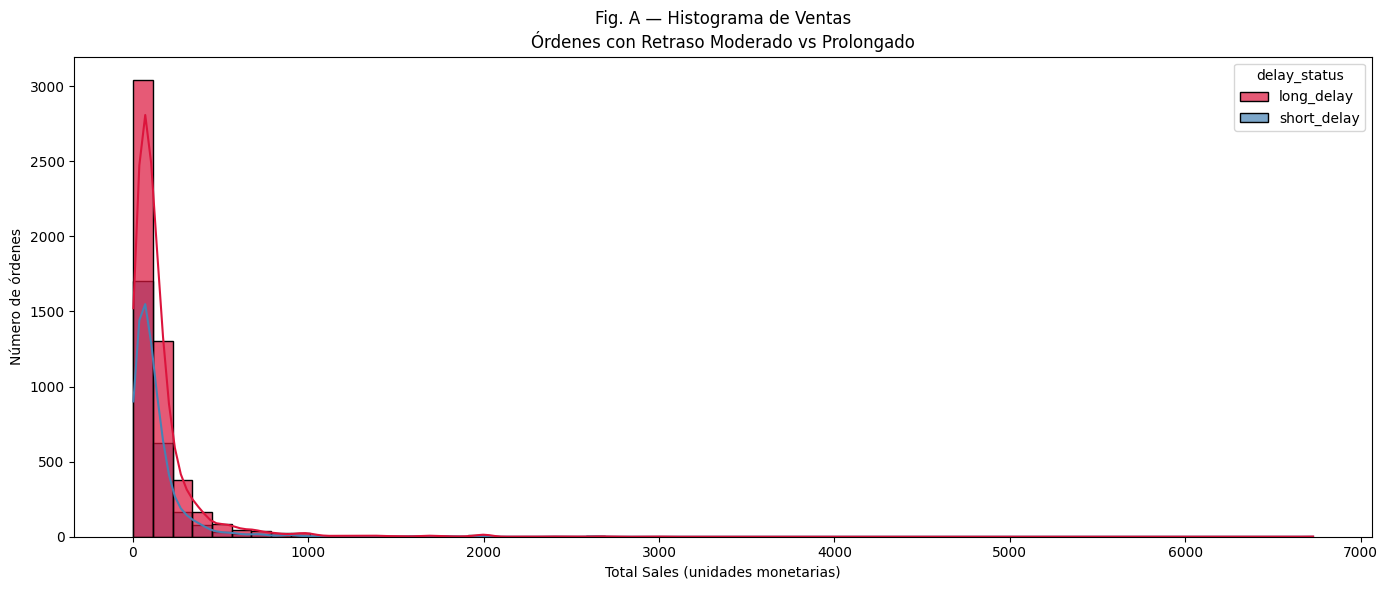

Guardado: 3_a_histogram_sales_short_long_delays.png


In [2]:
df_delays = delivered.query("delay_status in ['short_delay', 'long_delay']")

plt.figure(figsize=(14, 6))

sns.histplot(
    data=df_delays,
    x='total_sales',
    hue='delay_status',
    bins=60,
    palette={'short_delay': 'steelblue', 'long_delay': 'crimson'},
    alpha=0.7,
    kde=True
).set(
    title='Fig. A — Histograma de Ventas\n'
          'Órdenes con Retraso Moderado vs Prolongado',
    xlabel='Total Sales (unidades monetarias)',
    ylabel='Número de órdenes'
)

plt.tight_layout()
plt.savefig('3_a_histogram_sales_short_long_delays.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: 3_a_histogram_sales_short_long_delays.png')

---
## Entregable B — Matriz de correlación para órdenes completadas

Heatmap de correlación de Pearson entre las variables numéricas clave.

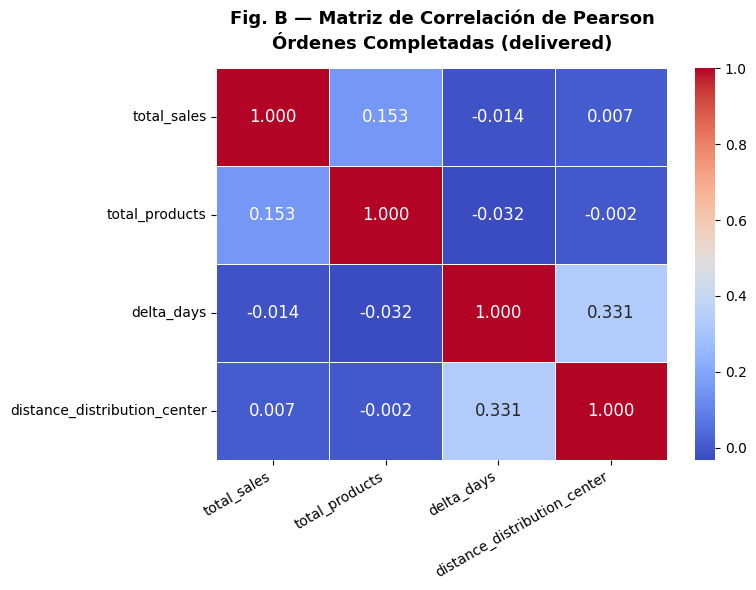

Guardado: 3_b_correlation_matrix_complete_orders.png


In [3]:
cols_corr = ['total_sales', 'total_products', 'delta_days', 'distance_distribution_center']
matrix_corr = delivered.filter(cols_corr).corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    matrix_corr,
    cmap='coolwarm',
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    annot_kws={'size': 12},
    ax=ax
)

ax.set_title(
    'Fig. B — Matriz de Correlación de Pearson\n'
    'Órdenes Completadas (delivered)',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('3_b_correlation_matrix_complete_orders.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: 3_b_correlation_matrix_complete_orders.png')

---
## Entregable C — Boxplots de `delta_days` por estado de Brasil y `delay_status`

Panel de diagramas de caja con `catplot`, un panel por tipo de retraso, estados ordenados por mediana de `delta_days`.

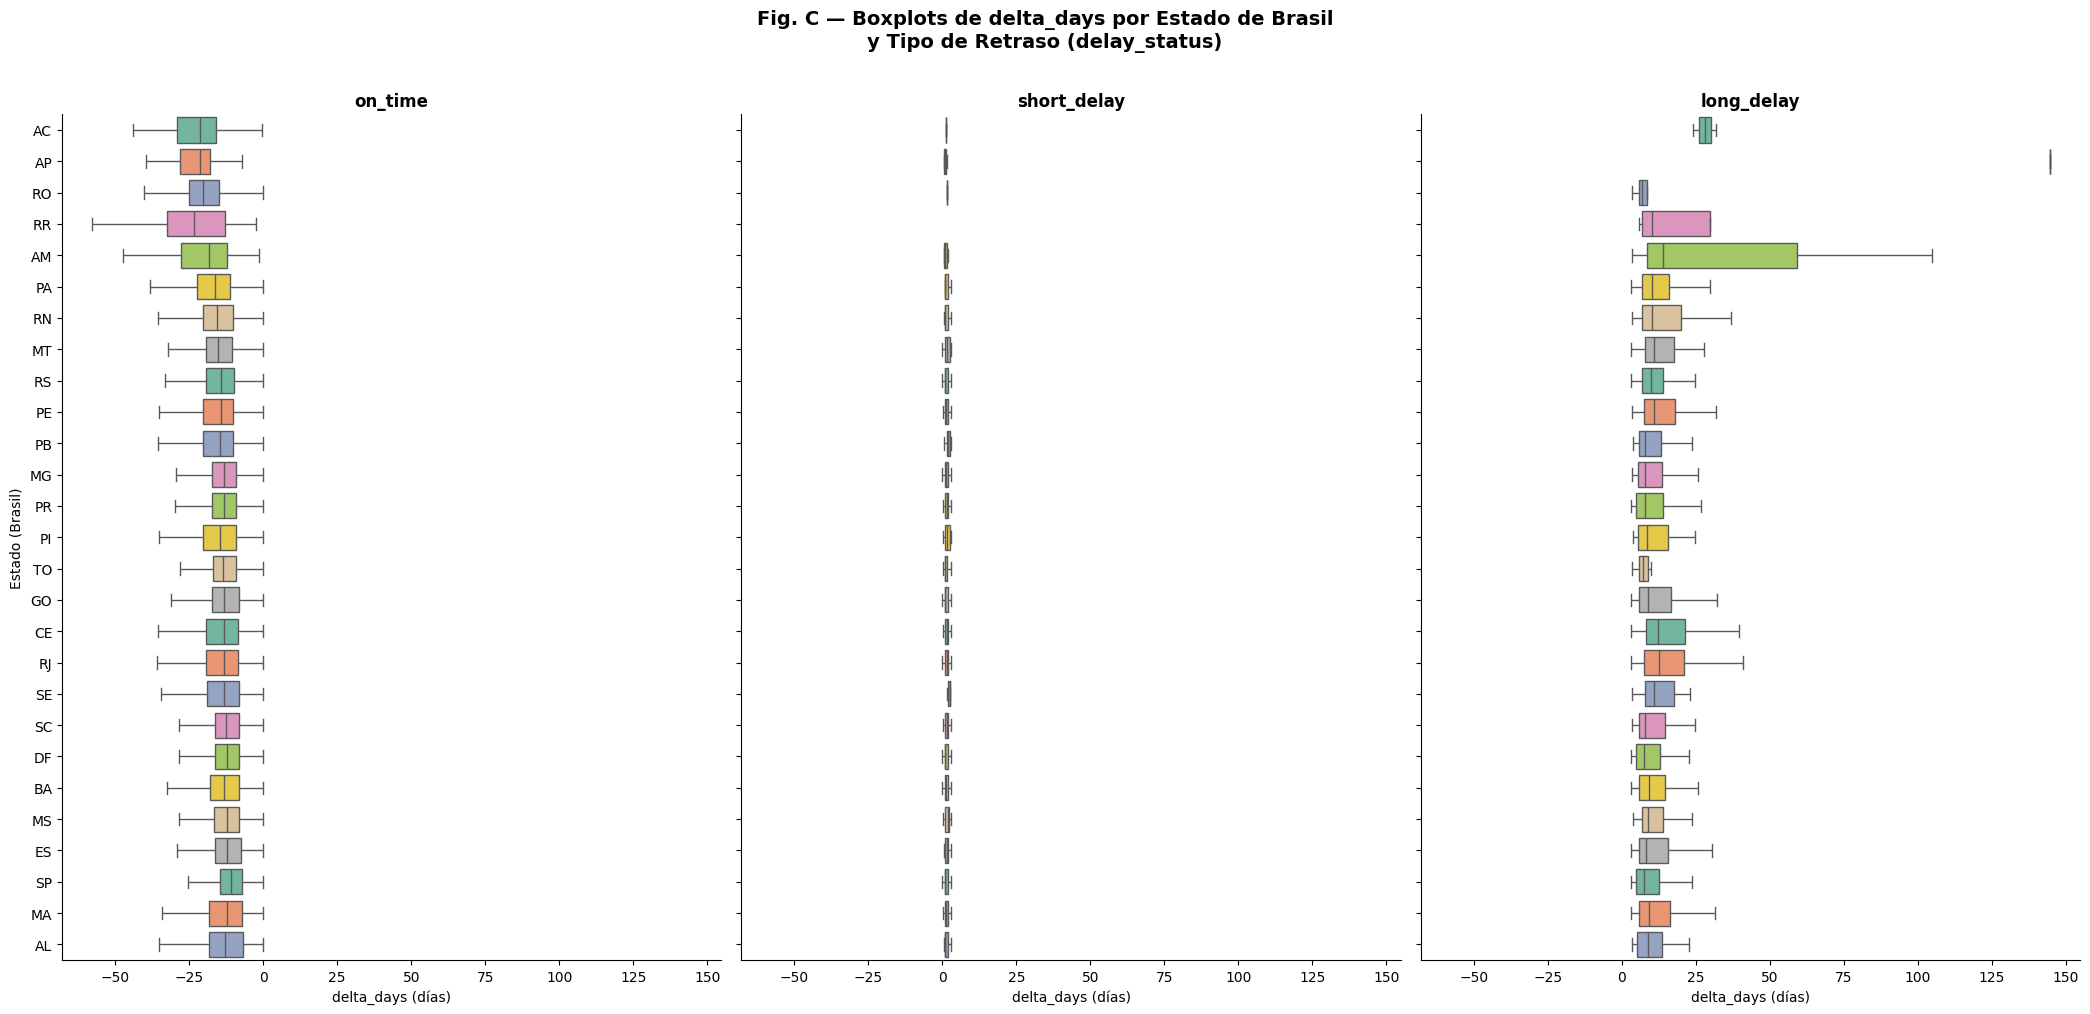

Guardado: 3_c_boxplot_delta_day_by_state_and_delay_type.png


In [4]:
# Estados ordenados por mediana de delta_days
state_order = (
    delivered.groupby('customer_state')['delta_days']
    .median().sort_values().index.tolist()
)

g = sns.catplot(
    data=delivered,
    x='delta_days',
    y='customer_state',
    col='delay_status',
    kind='box',
    order=state_order,
    col_order=['on_time', 'short_delay', 'long_delay'],
    showfliers=False,
    height=10,
    aspect=0.7,
    palette='Set2'
)

g.set_titles(col_template='{col_name}', size=12, fontweight='bold')
g.set_axis_labels('delta_days (días)', 'Estado (Brasil)')
g.figure.suptitle(
    'Fig. C — Boxplots de delta_days por Estado de Brasil\n'
    'y Tipo de Retraso (delay_status)',
    y=1.01, fontsize=14, fontweight='bold'
)

plt.tight_layout()
plt.savefig('3_c_boxplot_delta_day_by_state_and_delay_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: 3_c_boxplot_delta_day_by_state_and_delay_type.png')